In [ ]:
### Modelo UNET V3 ###
import tensorflow as tf # type: ignore
import pathlib
import matplotlib.pyplot as plt
import os
import numpy as np
from dotenv import load_dotenv


### 1. Configurar o caminho e criar lista de imagens ###
load_dotenv()
print(f"Arquivo .env carregado: {load_dotenv()}")

img_dir_str = os.getenv("BASE_IMG_FOLDER")
print(f"BASE_IMG_FOLDER: {os.getenv('BASE_IMG_FOLDER')}")
if img_dir_str is None:
    raise ValueError("A variável de ambiente BASE_IMG_FOLDER não está definida no arquivo .env")
img_dir = pathlib.Path(img_dir_str)

mask_dir_str = os.getenv("NUMPY_FOLDER")
print(f"NUMPY_FOLDER: {os.getenv('NUMPY_FOLDER')}")
if mask_dir_str is None:
    raise ValueError("A variável de ambiente NUMPY_FOLDER não está definida no arquivo .env")
mask_dir = pathlib.Path(mask_dir_str)

# Verificar se o diretório existe
if not os.path.exists(mask_dir):
    raise ValueError(f"Diretório não encontrado: {mask_dir}")

# Função para extrair o número do nome do arquivo
def get_file_number(filepath):
    return int(os.path.basename(filepath).replace('.png', ''))
def get_file_number_mask(filepath):
    return int(os.path.basename(filepath).replace('.npy', ''))

# Verificar se os arquivos existem e converter PosixPath para strings 
mask_files = []
for path in mask_dir.glob('*.npy'):
    if os.path.exists(path):
        mask_files.append(str(path))

image_files = []
for path in img_dir.glob('*.png'):
    if os.path.exists(path):
        image_files.append(str(path))

# Ordenar a lista usando o número do arquivo como chave
image_files = sorted(image_files, key=get_file_number)
mask_files = sorted(mask_files, key=get_file_number_mask)


### 2. Pré Processamento ###
def load_and_preprocess_image_mask(image_path, mask_path):
    try:
        # Carregar imagem RGB
        img = tf.io.read_file(image_path)
        img = tf.image.decode_png(img, channels=3)
        img = tf.image.resize(img, [512, 512])  # Redimensionar o tamanho
        img = tf.cast(img, tf.float32) / 255.0  # Normalizar a imagem

        # Carregar máscara do arquivo numpy
        mask = np.load(mask_path.numpy().decode())  # Ler a máscara
        mask = tf.convert_to_tensor(mask, dtype=tf.float32)  # Converter como tensor

        # Normalizar máscara
        mask = mask / 255.0  # Converter valores de 0-255 a 0-1
        mask = tf.where(mask >= 0.3, 1.0, 0.0)  # Binarizar a máscara

        return img, mask

    except Exception as e:
        print(f"Erro ao processar imagem/máscara {image_path}, {mask_path}: {str(e)}")
        raise


## Função para aplicar aumento de dados considerando máscaras como arrays multicamadas
def augment_image_mask(image, mask):
    # Gere um valor aleatório comum para transformações
    flip_left_right = tf.random.uniform(shape=[]) > 0.5
    flip_up_down = tf.random.uniform(shape=[]) > 0.5
    k = tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32)  # 0, 90, 180, 270 graus

    # Flip horizontal
    if flip_left_right:
        image = tf.image.flip_left_right(image)
        mask = tf.image.flip_left_right(mask)

    # Flip vertical
    if flip_up_down:
        image = tf.image.flip_up_down(image)
        mask = tf.image.flip_up_down(mask)

    # Aplicar rotação à imagem
    image = tf.image.rot90(image, k=k)

    # Aplique rotação à máscara em toda a sua dimensão
    mask = tf.image.rot90(mask, k=k)  # Agora giramos a máscara inteira de uma vez

    # Configurações adicionais de imagem
    image = tf.image.random_brightness(image, max_delta=0.1)
    image = tf.image.random_contrast(image, 0.8, 1.2)

    return image, mask

# Converter listas de rotas em conjunto de dados do TensorFlow
def process_path(image_path, mask_path):
    img, mask = tf.py_function(load_and_preprocess_image_mask, [image_path, mask_path], [tf.float32, tf.float32])
    img.set_shape((512, 512, 3))  # Defina o tamanho esperado da imagem
    mask.set_shape((512, 512, 22))  # Defina o tamanho esperado da máscara
    return img, mask

# Criar um conjunto de dados a partir de listas de imagens e máscaras
train_dataset = tf.data.Dataset.from_tensor_slices((image_files, mask_files))
train_dataset = train_dataset.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)

# Aplicar Aumento de Dados
train_dataset = train_dataset.map(lambda img, mask: augment_image_mask(img, mask), num_parallel_calls=tf.data.AUTOTUNE)

### Configurar o conjunto de dados ###
BUFFER_SIZE = 32
BATCH_SIZE = 8

train_dataset = (
    train_dataset
    .shuffle(BUFFER_SIZE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# Inspecionar o conjunto de dados
for img, mask in train_dataset.take(1):
    print(f"Imagem em lote: {img.shape}")  # Esperado: (batch_size, 512, 512, 3)
    print(f"Máscara em lote: {mask.shape}")  # Esperado: (batch_size, 512, 512, 22)


### 3. Modelo UNET ###
def unet_multilabel_v3(input_shape=(512, 512, 3), num_classes=22):
    # Input
    inputs = tf.keras.layers.Input(shape=input_shape)
    
    # Encoder (Downsampling)
    def encoder_block(x, filters, kernel_size=(3, 3), padding="same", dropout_rate=0.1):
        x = tf.keras.layers.Conv2D(filters, kernel_size, padding=padding, activation=None)(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.Activation("relu")(x)
        x = tf.keras.layers.Conv2D(filters, kernel_size, padding=padding, activation=None)(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.Activation("relu")(x)
        x = tf.keras.layers.Dropout(dropout_rate)(x)
        return x

    # Encoder - mantendo a estrutura original de 3 níveis, mas com separação entre normalização e ativação
    e1 = encoder_block(inputs, 64)
    p1 = tf.keras.layers.MaxPooling2D((2, 2))(e1)
    
    e2 = encoder_block(p1, 128)
    p2 = tf.keras.layers.MaxPooling2D((2, 2))(e2)
    
    e3 = encoder_block(p2, 256)
    p3 = tf.keras.layers.MaxPooling2D((2, 2))(e3)
    
    # Bottleneck - com um número moderado de filtros
    bottleneck = encoder_block(p3, 512, dropout_rate=0.3)
    
    # Decoder (Upsampling) - estrutura aprimorada mas sem camadas extra
    def decoder_block(x, skip_features, filters, kernel_size=(3, 3), padding="same", dropout_rate=0.1):
        # Upsampling
        x = tf.keras.layers.UpSampling2D((2, 2))(x)
        
        # Camada de convolução após upsampling
        x = tf.keras.layers.Conv2D(filters, (2, 2), padding="same", activation=None)(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.Activation("relu")(x)
        
        # Concatenate com skip connection
        x = tf.keras.layers.Concatenate()([x, skip_features])
        
        # Convolução com normalização e ativação separadas
        x = tf.keras.layers.Conv2D(filters, kernel_size, padding=padding, activation=None)(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.Activation("relu")(x)
        
        x = tf.keras.layers.Conv2D(filters, kernel_size, padding=padding, activation=None)(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.Activation("relu")(x)
        
        x = tf.keras.layers.Dropout(dropout_rate)(x)
        
        return x
    
    # Decoder - mantendo estrutura original de 3 níveis
    d3 = decoder_block(bottleneck, e3, 256, dropout_rate=0.1)
    d2 = decoder_block(d3, e2, 128, dropout_rate=0.1)
    d1 = decoder_block(d2, e1, 64, dropout_rate=0.1)
    
    # Mecanismo de atenção simplificado
    attention_gate = tf.keras.layers.Conv2D(1, (1, 1), padding="same", activation="sigmoid")(d1)
    attention_features = tf.keras.layers.Multiply()([d1, attention_gate])
    
    # Output com sigmoid activation para multilabel binary masks
    outputs = tf.keras.layers.Conv2D(num_classes, (1, 1), activation="sigmoid")(attention_features)
    
    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    return model


# Create model
model = unet_multilabel_v3()
model.summary()

### 4. Amostras ###
# Obter o número total de amostras no conjunto de dados sem lote prévio
dataset = tf.data.Dataset.from_tensor_slices((image_files, mask_files))
dataset = dataset.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
dataset_size = tf.data.experimental.cardinality(dataset).numpy()

# Definir proporções para treinar, validar e testar
train_size = int(0.8 * dataset_size)
val_size = int(0.1 * dataset_size)
test_size = dataset_size - train_size - val_size

# Mesclar o conjunto de dados antes de dividir
shuffled_dataset = dataset.shuffle(BUFFER_SIZE)
shuffled_dataset = shuffled_dataset.shuffle(BUFFER_SIZE)

# Divida o conjunto de dados ANTES de aplicar o lote para evitar o problema de lote duplo
train_dataset = shuffled_dataset.take(train_size)
remaining_dataset = shuffled_dataset.skip(train_size)
val_dataset = remaining_dataset.take(val_size)
test_dataset = remaining_dataset.skip(val_size)

# Aplicar aumento de dados apenas ao conjunto de treinamento
train_dataset = train_dataset.map(lambda img, mask: augment_image_mask(img, mask), num_parallel_calls=tf.data.AUTOTUNE)

# Aplicar lote após divisão
train_dataset = train_dataset.batch(BATCH_SIZE).prefetch(1)
val_dataset = val_dataset.batch(BATCH_SIZE).prefetch(1)
test_dataset = test_dataset.batch(BATCH_SIZE).prefetch(1)


### 5. Redefinição da Perda ###
def dice_coef(y_true, y_pred, smooth=1e-6):
    """
    Calcula o coeficiente Dice entre as máscaras verdadeiras e preditas
    """
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    """
    Calcula o Dice Loss (1 - coeficiente Dice)
    """
    return 1 - dice_coef(y_true, y_pred)

def multilabel_dice_loss(y_true, y_pred):
    """
    Aplica Dice Loss para cada canal (classe) e calcula a média
    """
    loss = 0
    for i in range(y_pred.shape[-1]):  # Iterar por cada classe
        loss += dice_loss(y_true[..., i], y_pred[..., i])
    
    # Retorna a média das perdas em todas as classes
    return loss / y_pred.shape[-1]

def bce_dice_loss(y_true, y_pred, dice_weight=0.5):
    """
    Combinação de BCE e Dice Loss
    
    Parâmetros:
    - dice_weight: Peso dado ao Dice Loss (0 a 1) 0 = apenas BCE, 1 = apenas Dice

    Considerações:
    Ajuste do peso do Dice Loss.
    Inicialmente, estamos usando um equilíbrio 50/50 entre BCE e Dice Loss (dice_weight=0.5). 
    Dependendo dos resultados, pode ser necessário ajustar este peso para dar mais importância a um ou outro componente:
        Para focar mais na qualidade das bordas: aumente o peso para dice_weight=0.7;
        Para focar mais na classificação a nível de pixel: reduza para dice_weight=0.3.
    """
    bce = tf.keras.losses.BinaryCrossentropy(from_logits=False)(y_true, y_pred)
    dice = multilabel_dice_loss(y_true, y_pred)
    
    return (1 - dice_weight) * bce + dice_weight * dice

def loss_function(y_true, y_pred):
    return bce_dice_loss(y_true, y_pred, dice_weight=0.5)


### 6. Redefinição da métrica IoU ###
class MulticlassIoU(tf.keras.metrics.Metric):
    def __init__(self, num_classes=22, threshold=0.5, name='multiclass_iou', **kwargs):
        super(MulticlassIoU, self).__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.threshold = threshold
        self.total_iou = self.add_weight(name='total_iou', initializer='zeros')
        self.count = self.add_weight(name='count', initializer='zeros')
        
    def update_state(self, y_true, y_pred, sample_weight=None):
        # Binarize predictions
        y_pred = tf.cast(y_pred > self.threshold, tf.float32)
        
        # Calculate intersection and union for all classes at once
        intersection = tf.reduce_sum(y_true * y_pred, axis=[0, 1, 2])
        union = tf.reduce_sum(y_true, axis=[0, 1, 2]) + tf.reduce_sum(y_pred, axis=[0, 1, 2]) - intersection
        
        # Calculate IoU for each class
        iou = tf.where(union > 0, intersection / (union + 1e-10), tf.ones_like(intersection))
        
        # Calculate mean IoU across all classes
        mean_iou = tf.reduce_mean(iou)
        
        # Update metric state
        self.total_iou.assign_add(mean_iou)
        self.count.assign_add(1.0)
        
    def result(self):
        return self.total_iou / (self.count + 1e-10)
    
    def reset_state(self):
        self.total_iou.assign(0.0)
        self.count.assign(0.0)


### 7. Treinamento ###
# Callbacks para melhorar o treinamento
callbacks = [
    # Early stopping para evitar Overfitting (sobreajuste)
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,  # Permitir mais épocas antes de se deter se não houver melhor
        restore_best_weights=True,
        verbose=1
    ),

    # Salvar o melhor modelo baseado na menor perda de validação
    tf.keras.callbacks.ModelCheckpoint(
        # filepath='best_model_focal_v2.keras',     # model_v2
        filepath='best_model_bce_dice_v3.keras',    # model_v3
        save_best_only=True,
        monitor='val_loss',
        mode='min',
        verbose=1
    ),

    # Reduza a taxa de aprendizagem se a perda de validação persistir
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,  # Reduza a tarefa de aprendizagem para a metade se não for melhor
        patience=5,  # Esperar 5 épocas sem melhorar antes de reduzir
        min_lr=1e-6,  # Limite inferior para a tarefa de aprendizagem
        verbose=1
    ),

    # Registrador de métricas no TensorBoard
    tf.keras.callbacks.TensorBoard(
        # log_dir='logs_focal',     # model_v2
        log_dir='logs_bce_dice_v3', # model_v3
        histogram_freq=1,
        write_graph=True,
        write_images=True
    )
]

# Compilar o modelo com perda focal e especificações específicas
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),  # Taxa de aprendizagem inicial
    loss=loss_function,
    metrics=[
        'accuracy', 
        MulticlassIoU(num_classes=22, threshold=0.5), # Implementação da métrica para multiclasse
        tf.keras.metrics.Precision(), 
        tf.keras.metrics.Recall()
    ]
)

# Definir a estratégia de treinamento em fases (ajuste fino)
EPOCHS_PHASE_1 = 75  # Treinamento inicial
EPOCHS_PHASE_2 = 25  # Ajuste fino

print("Treinamento: Fase 1 - Aprendizagem inicial")
history_1 = model.fit(
    train_dataset,
    epochs=EPOCHS_PHASE_1,
    validation_data=val_dataset,
    callbacks=callbacks,
    verbose=1
)

# Recompilar o modelo para a fase de ajuste fino com taxa de aprendizagem reduzida
print("Recompilando modelo para ajuste fino...")
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # Taxa reduzida para ajuste fino
    loss=loss_function,
    metrics=[
        'accuracy', 
        MulticlassIoU(num_classes=22, threshold=0.5), # Implementação da métrica para multiclasse
        tf.keras.metrics.Precision(), 
        tf.keras.metrics.Recall()
    ]
)

print("Treinamento: Fase 2 - Ajuste fino com taxa de aprendizagem reduzida")
history_2 = model.fit(
    train_dataset,
    epochs=EPOCHS_PHASE_2,
    validation_data=val_dataset,
    callbacks=callbacks,
    verbose=1
)


2025-04-14 20:36:43.556578: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Carregando modelo de best_model_bce_dice_v3.keras...


2025-04-14 20:36:48.832025: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-04-14 20:36:52.471249: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-04-14 20:36:52.471331: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-04-14 20:36:52.472733: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-04-14 20:36:52.472868: I external/local_xla/xla/stream_executor/rocm/rocm_executor.

Carregando conjunto de dados de teste...

Avaliando modelo no conjunto de teste...


I0000 00:00:1744663095.502280    4014 service.cc:146] XLA service 0x7f136801d4a0 initialized for platform ROCM (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1744663095.502323    4014 service.cc:154]   StreamExecutor device (0): AMD Radeon RX 7800 XT, AMDGPU ISA version: gfx1101
2025-04-14 20:38:15.713828: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1744663097.908967    4014 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


64/64 ━━━━━━━━━━━━━━━━━━━━ 102s 296ms/step - accuracy: 0.8176 - loss: 0.4778 - multiclass_iou: 0.3117 - precision: 0.8181 - recall: 0.8080

===== Métricas Gerais =====
Loss: 0.4791
Accuracy: 0.8186
Mean IoU: 0.3266
Precision: 0.8174
Recall: 0.8057

Processando métricas detalhadas incrementalmente...
Processando batch 1...
Processando batch 2...
Processando batch 3...
Processando batch 4...
Processando batch 5...
Processando batch 6...
Processando batch 7...
Processando batch 8...
Processando batch 9...
Processando batch 10...
Processando batch 11...
Processando batch 12...
Processando batch 13...
Processando batch 14...
Processando batch 15...
Processando batch 16...
Processando batch 17...
Processando batch 18...
Processando batch 19...
Processando batch 20...
Processando batch 21...
Processando batch 22...
Processando batch 23...
Processando batch 24...
Processando batch 25...
Processando batch 26...
Processando batch 27...
Processando batch 28...
Processando batch 29...
Processando 

2025-04-14 20:40:26.134684: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



===== Métricas Globais para o Artigo =====
IoU Global Médio: 0.0903
F1-Score Global: 0.1125
Precision Global: 0.1701
Recall Global: 0.1183

===== Verificação de Requisitos Mínimos =====
IoU Global Médio: 0.0903 (Mínimo aceitável: 0.75, Ideal: >0.85)
❌ IoU Global ABAIXO do mínimo aceitável
F1-Score Global: 0.1125 (Mínimo aceitável: 0.80, Ideal: >0.85)
❌ F1-Score Global ABAIXO do mínimo aceitável

===== Métricas por Classe =====
   Classe      IoU  Precision   Recall  F1-Score
 Classe_1 0.829317   0.875494 0.940203  0.906696
 Classe_2 0.000000   0.000000 0.000000  0.000000
 Classe_3 0.000000   0.000000 0.000000  0.000000
 Classe_4 0.000000   0.000000 0.000000  0.000000
 Classe_5 0.000000   0.000000 0.000000  0.000000
 Classe_6 0.000000   0.000000 0.000000  0.000000
 Classe_7 0.000000   0.000000 0.000000  0.000000
 Classe_8 0.000000   0.000000 0.000000  0.000000
 Classe_9 0.015241   0.766364 0.015312  0.030025
Classe_10 0.687075   0.721953 0.934306  0.814516
Classe_11 0.033858   0.037809

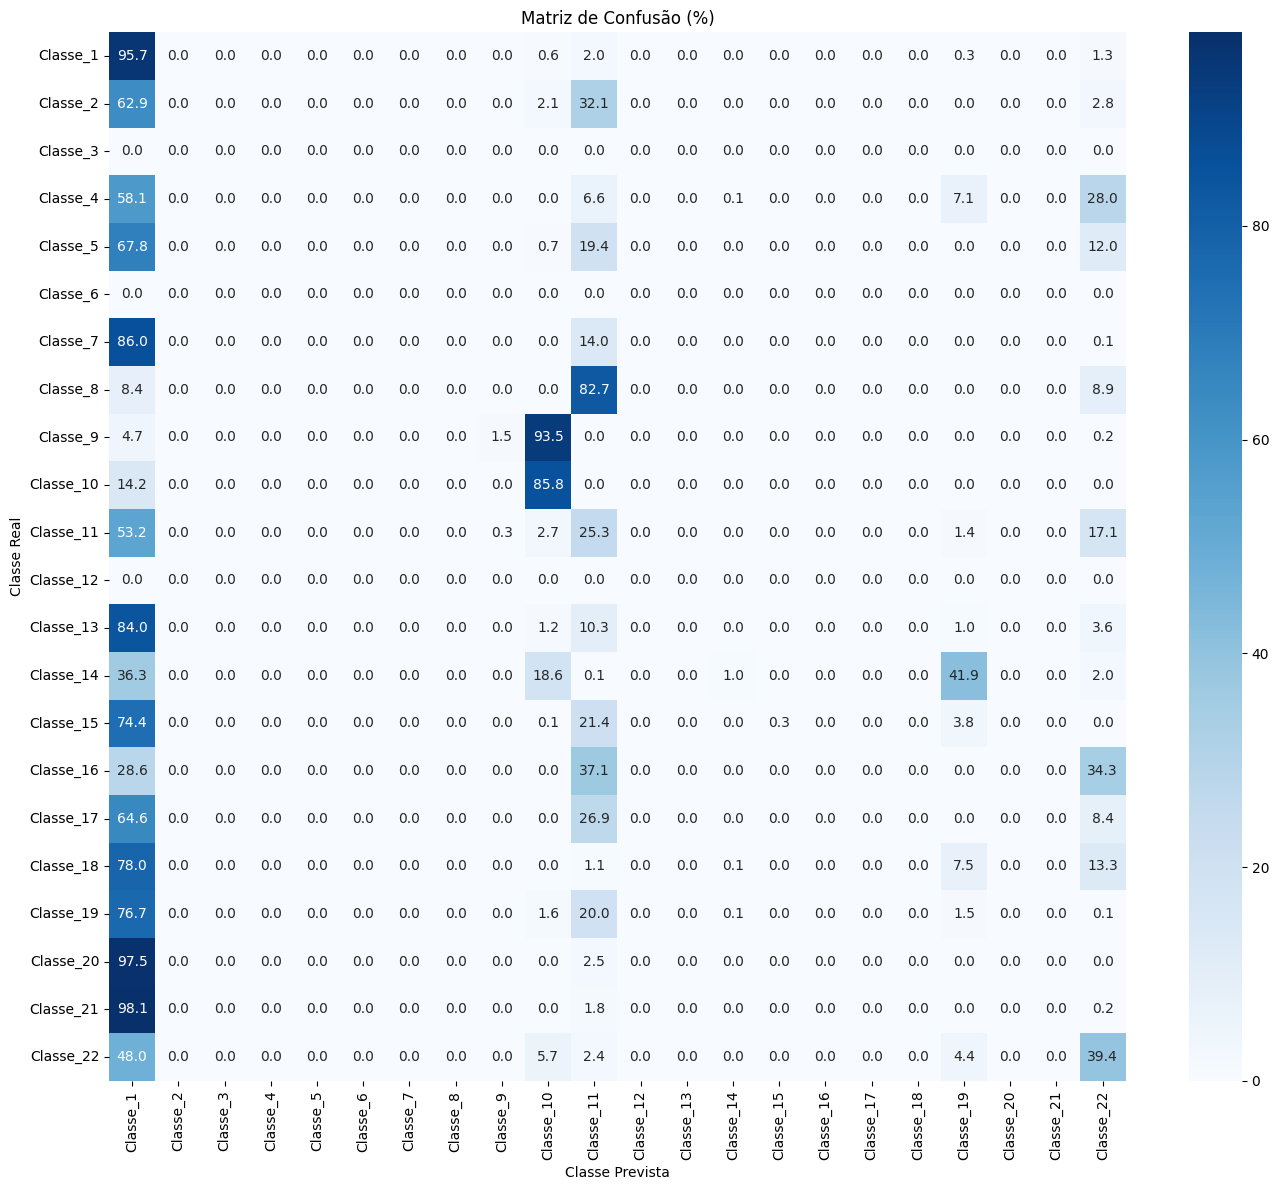


Gerando visualizações das métricas por classe...


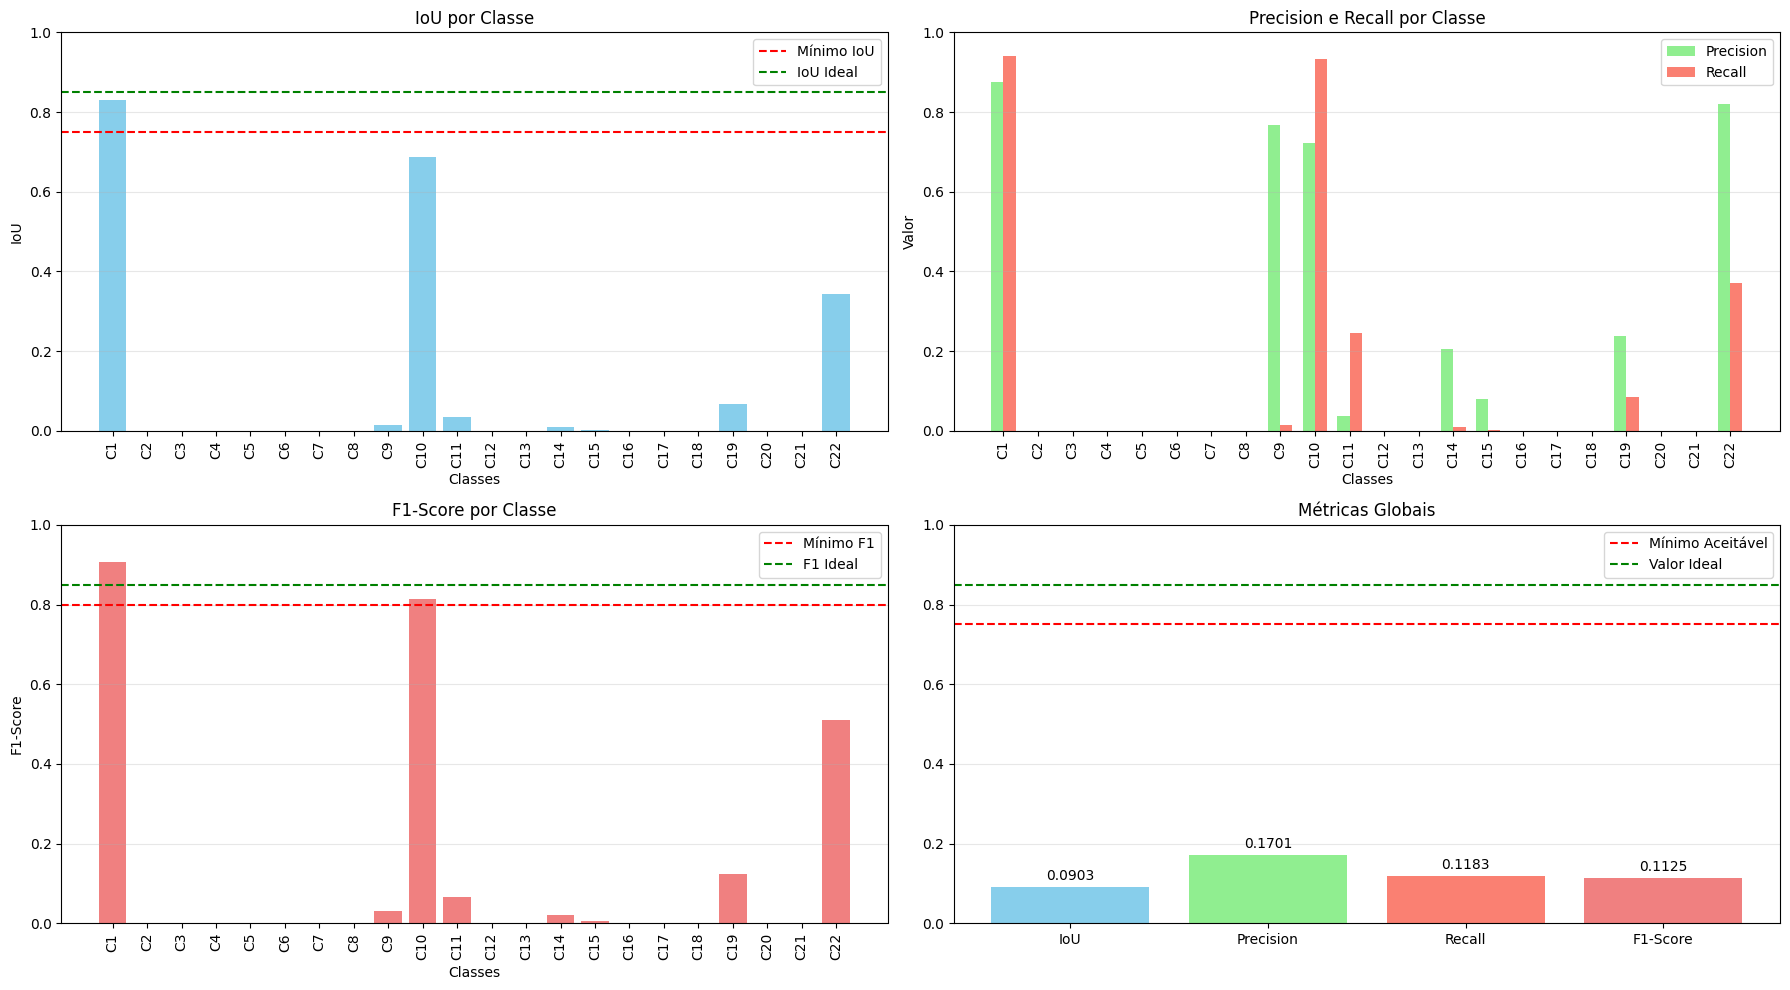


Resultados salvos em 'resultados_por_classe.csv' e 'metricas_globais.csv'


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pathlib
import os
from dotenv import load_dotenv
from sklearn.metrics import confusion_matrix

# Redefinir as funções necessárias para carregar o modelo treinado
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)

def multilabel_dice_loss(y_true, y_pred):
    loss = 0
    for i in range(y_pred.shape[-1]):
        loss += dice_loss(y_true[..., i], y_pred[..., i])
    return loss / y_pred.shape[-1]

def bce_dice_loss(y_true, y_pred, dice_weight=0.5):
    bce = tf.keras.losses.BinaryCrossentropy(from_logits=False)(y_true, y_pred)
    dice = multilabel_dice_loss(y_true, y_pred)
    return (1 - dice_weight) * bce + dice_weight * dice

def loss_function(y_true, y_pred):
    return bce_dice_loss(y_true, y_pred, dice_weight=0.5)

class MulticlassIoU(tf.keras.metrics.Metric):
    def __init__(self, num_classes=22, threshold=0.5, name='multiclass_iou', **kwargs):
        super(MulticlassIoU, self).__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.threshold = threshold
        self.total_iou = self.add_weight(name='total_iou', initializer='zeros')
        self.count = self.add_weight(name='count', initializer='zeros')
        
    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred = tf.cast(y_pred > self.threshold, tf.float32)
        intersection = tf.reduce_sum(y_true * y_pred, axis=[0, 1, 2])
        union = tf.reduce_sum(y_true, axis=[0, 1, 2]) + tf.reduce_sum(y_pred, axis=[0, 1, 2]) - intersection
        iou = tf.where(union > 0, intersection / (union + 1e-10), tf.ones_like(intersection))
        mean_iou = tf.reduce_mean(iou)
        self.total_iou.assign_add(mean_iou)
        self.count.assign_add(1.0)
        
    def result(self):
        return self.total_iou / (self.count + 1e-10)
    
    def reset_state(self):
        self.total_iou.assign(0.0)
        self.count.assign(0.0)

def load_test_dataset():
    """
    Carrega o conjunto de dados de teste
    """
    # Carregar variáveis de ambiente
    load_dotenv()
    
    img_dir_str = os.getenv("BASE_IMG_FOLDER")
    if img_dir_str is None:
        raise ValueError("A variável de ambiente BASE_IMG_FOLDER não está definida no arquivo .env")
    img_dir = pathlib.Path(img_dir_str)
    
    mask_dir_str = os.getenv("NUMPY_FOLDER")
    if mask_dir_str is None:
        raise ValueError("A variável de ambiente NUMPY_FOLDER não está definida no arquivo .env")
    mask_dir = pathlib.Path(mask_dir_str)
    
    # Funções para extrair número do arquivo
    def get_file_number(filepath):
        return int(os.path.basename(filepath).replace('.png', ''))
    
    def get_file_number_mask(filepath):
        return int(os.path.basename(filepath).replace('.npy', ''))
    
    # Listar arquivos
    mask_files = [str(path) for path in mask_dir.glob('*.npy') if os.path.exists(path)]
    image_files = [str(path) for path in img_dir.glob('*.png') if os.path.exists(path)]
    
    # Ordenar
    image_files = sorted(image_files, key=get_file_number)
    mask_files = sorted(mask_files, key=get_file_number_mask)
    
    def load_and_preprocess_image_mask(image_path, mask_path):
        try:
            # Carregar imagem
            img = tf.io.read_file(image_path)
            img = tf.image.decode_png(img, channels=3)
            img = tf.image.resize(img, [512, 512])
            img = tf.cast(img, tf.float32) / 255.0
            
            # Carregar máscara
            mask = np.load(mask_path.numpy().decode())
            mask = tf.convert_to_tensor(mask, dtype=tf.float32)
            mask = mask / 255.0
            mask = tf.where(mask >= 0.3, 1.0, 0.0)
            
            return img, mask
        except Exception as e:
            print(f"Erro ao processar {image_path}, {mask_path}: {str(e)}")
            raise
    
    def process_path(image_path, mask_path):
        img, mask = tf.py_function(load_and_preprocess_image_mask, [image_path, mask_path], [tf.float32, tf.float32])
        img.set_shape((512, 512, 3))
        mask.set_shape((512, 512, 22))
        return img, mask
    
    # Criar dataset
    dataset = tf.data.Dataset.from_tensor_slices((image_files, mask_files))
    dataset = dataset.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
    
    # Dividir dataset (mesma lógica do código original)
    dataset_size = tf.data.experimental.cardinality(dataset).numpy()
    train_size = int(0.8 * dataset_size)
    val_size = int(0.1 * dataset_size)
    
    # Dividir usando a mesma metodologia do treinamento
    shuffled_dataset = dataset.shuffle(buffer_size=32)
    train_dataset = shuffled_dataset.take(train_size)
    remaining_dataset = shuffled_dataset.skip(train_size)
    val_dataset = remaining_dataset.take(val_size)
    test_dataset = remaining_dataset.skip(val_size)
    
    # Configurar batch
    test_dataset = test_dataset.batch(8).prefetch(1)
    
    return test_dataset

def process_batch_metrics(y_true_batch, y_pred_batch, threshold=0.5, num_classes=22):
    """
    Processa métricas para um único batch
    Retorna IoU, Precision, Recall, F1 e contribuição para a matriz de confusão
    """
    y_pred_binary = tf.cast(y_pred_batch > threshold, tf.float32)
    
    # Arrays para armazenar resultados deste batch
    batch_tp = np.zeros(num_classes)
    batch_fp = np.zeros(num_classes)
    batch_fn = np.zeros(num_classes)
    batch_tn = np.zeros(num_classes)
    
    # Calcular métricas para cada classe
    for i in range(num_classes):
        y_true_class = y_true_batch[..., i]
        y_pred_class = y_pred_binary[..., i]
        
        # True Positives, False Positives, False Negatives
        tp = tf.reduce_sum(y_true_class * y_pred_class).numpy()
        fp = tf.reduce_sum((1 - y_true_class) * y_pred_class).numpy()
        fn = tf.reduce_sum(y_true_class * (1 - y_pred_class)).numpy()
        tn = tf.reduce_sum((1 - y_true_class) * (1 - y_pred_class)).numpy()
        
        batch_tp[i] = tp
        batch_fp[i] = fp
        batch_fn[i] = fn
        batch_tn[i] = tn
    
    # Para a matriz de confusão, transformamos os rótulos multiclasse em classes únicas
    # (pegando o índice de maior probabilidade para cada pixel)
    y_true_argmax = tf.argmax(y_true_batch, axis=-1).numpy().flatten()
    y_pred_argmax = tf.argmax(y_pred_binary, axis=-1).numpy().flatten()
    
    # Computar a matriz de confusão para este batch
    batch_cm = confusion_matrix(y_true_argmax, y_pred_argmax, 
                                labels=range(num_classes))
    
    return batch_tp, batch_fp, batch_fn, batch_tn, batch_cm

def calculate_final_metrics(total_tp, total_fp, total_fn, total_tn, num_classes):
    """
    Calcula métricas finais a partir dos totais acumulados
    """
    iou_per_class = np.zeros(num_classes)
    precision_per_class = np.zeros(num_classes)
    recall_per_class = np.zeros(num_classes)
    f1_per_class = np.zeros(num_classes)
    
    for i in range(num_classes):
        # IoU = TP / (TP + FP + FN)
        iou_per_class[i] = total_tp[i] / (total_tp[i] + total_fp[i] + total_fn[i] + 1e-10)
        
        # Precision = TP / (TP + FP)
        precision_per_class[i] = total_tp[i] / (total_tp[i] + total_fp[i] + 1e-10)
        
        # Recall = TP / (TP + FN)
        recall_per_class[i] = total_tp[i] / (total_tp[i] + total_fn[i] + 1e-10)
        
        # F1 Score = 2 * (Precision * Recall) / (Precision + Recall)
        f1_per_class[i] = 2 * precision_per_class[i] * recall_per_class[i] / (precision_per_class[i] + recall_per_class[i] + 1e-10)
    
    return iou_per_class, precision_per_class, recall_per_class, f1_per_class

def plot_confusion_matrix(cm, class_names=None, figsize=(14, 12), cmap='Blues', save_path=None):
    """
    Plota a matriz de confusão
    """
    if class_names is None:
        class_names = [f'Classe {i+1}' for i in range(cm.shape[0])]
    
    plt.figure(figsize=figsize)
    
    # Normalizar para porcentagens por linha (classe verdadeira)
    cm_normalized = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-10) * 100
    
    sns.heatmap(cm_normalized, annot=True, fmt='.1f', cmap=cmap,
                xticklabels=class_names, yticklabels=class_names)
    
    plt.ylabel('Classe Real')
    plt.xlabel('Classe Prevista')
    plt.title('Matriz de Confusão (%)')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()

def evaluate_and_report(model_path='best_model_bce_dice_v3.keras', num_classes=22):
    """
    Função principal para avaliar o modelo e gerar relatório completo
    Versão modificada para processar incrementalmente (evitar OOM)
    """
    # Definir nomes das classes (substitua pelos nomes reais se disponíveis)
    class_names = [f'Classe_{i+1}' for i in range(num_classes)]
    
    # Verificar se o modelo existe
    if not os.path.exists(model_path):
        raise ValueError(f"Modelo não encontrado: {model_path}")
    
    # Carregar modelo
    print(f"Carregando modelo de {model_path}...")
    custom_objects = {
        'loss_function': loss_function,
        'MulticlassIoU': MulticlassIoU,
        'dice_coef': dice_coef,
        'dice_loss': dice_loss,
        'multilabel_dice_loss': multilabel_dice_loss
    }
    
    model = tf.keras.models.load_model(model_path, custom_objects=custom_objects)
    
    # Carregar conjunto de teste
    print("Carregando conjunto de dados de teste...")
    test_dataset = load_test_dataset()
    
    # Avaliar modelo com métricas padrão
    print("\nAvaliando modelo no conjunto de teste...")
    test_loss, test_acc, test_iou, test_precision, test_recall = model.evaluate(test_dataset, verbose=1)
    
    print("\n===== Métricas Gerais =====")
    print(f"Loss: {test_loss:.4f}")
    print(f"Accuracy: {test_acc:.4f}")
    print(f"Mean IoU: {test_iou:.4f}")
    print(f"Precision: {test_precision:.4f}")
    print(f"Recall: {test_recall:.4f}")
    
    # Inicializar contadores para todas as classes
    total_tp = np.zeros(num_classes)
    total_fp = np.zeros(num_classes)
    total_fn = np.zeros(num_classes)
    total_tn = np.zeros(num_classes)
    
    # Inicializar matriz de confusão
    total_cm = np.zeros((num_classes, num_classes), dtype=np.int64)
    
    # Processar batch por batch para evitar OOM
    print("\nProcessando métricas detalhadas incrementalmente...")
    batch_count = 0
    
    for images, masks in test_dataset:
        batch_count += 1
        print(f"Processando batch {batch_count}...")
        
        # Fazer previsões para este batch
        predictions = model.predict(images, verbose=0)
        
        # Processar métricas para este batch
        batch_tp, batch_fp, batch_fn, batch_tn, batch_cm = process_batch_metrics(
            masks, predictions, threshold=0.5, num_classes=num_classes
        )
        
        # Acumular resultados
        total_tp += batch_tp
        total_fp += batch_fp
        total_fn += batch_fn
        total_tn += batch_tn
        total_cm += batch_cm
    
    # Calcular métricas finais a partir dos valores acumulados
    iou_per_class, precision_per_class, recall_per_class, f1_per_class = calculate_final_metrics(
        total_tp, total_fp, total_fn, total_tn, num_classes
    )
    
    # Calcular médias globais
    global_iou = np.mean(iou_per_class)
    global_f1 = np.mean(f1_per_class)
    global_precision = np.mean(precision_per_class)
    global_recall = np.mean(recall_per_class)
    
    # Criar DataFrame de resultados
    results_df = pd.DataFrame({
        'Classe': class_names,
        'IoU': iou_per_class,
        'Precision': precision_per_class,
        'Recall': recall_per_class,
        'F1-Score': f1_per_class
    })
    
    # Mostrar métricas globais (importantes para o artigo)
    print("\n===== Métricas Globais para o Artigo =====")
    print(f"IoU Global Médio: {global_iou:.4f}")
    print(f"F1-Score Global: {global_f1:.4f}")
    print(f"Precision Global: {global_precision:.4f}")
    print(f"Recall Global: {global_recall:.4f}")
    
    # Verificar se atende aos requisitos mínimos
    print("\n===== Verificação de Requisitos Mínimos =====")
    print(f"IoU Global Médio: {global_iou:.4f} (Mínimo aceitável: 0.75, Ideal: >0.85)")
    if global_iou >= 0.85:
        print("✅ IoU Global IDEAL alcançado!")
    elif global_iou >= 0.75:
        print("✅ IoU Global ACEITÁVEL alcançado")
    else:
        print("❌ IoU Global ABAIXO do mínimo aceitável")
    
    print(f"F1-Score Global: {global_f1:.4f} (Mínimo aceitável: 0.80, Ideal: >0.85)")
    if global_f1 >= 0.85:
        print("✅ F1-Score Global IDEAL alcançado!")
    elif global_f1 >= 0.80:
        print("✅ F1-Score Global ACEITÁVEL alcançado")
    else:
        print("❌ F1-Score Global ABAIXO do mínimo aceitável")
    
    # Ordenar classes por IoU para identificar as mais desafiadoras
    results_sorted = results_df.sort_values('IoU')
    
    print("\n===== Métricas por Classe =====")
    print(results_df.to_string(index=False))
    
    print("\n===== Classes Mais Desafiadoras (Menor IoU) =====")
    print(results_sorted.head(5).to_string(index=False))
    
    # Gerar matriz de confusão
    print("\nGerando matriz de confusão...")
    plot_confusion_matrix(total_cm, class_names, save_path='confusion_matrix.png')
    
    # Visualizar métricas por classe em gráficos
    print("\nGerando visualizações das métricas por classe...")
    plt.figure(figsize=(18, 10))
    
    # IoU por classe
    plt.subplot(2, 2, 1)
    bars = plt.bar(range(len(class_names)), iou_per_class, color='skyblue')
    plt.axhline(y=0.75, color='r', linestyle='--', label='Mínimo IoU')
    plt.axhline(y=0.85, color='g', linestyle='--', label='IoU Ideal')
    plt.title('IoU por Classe')
    plt.xlabel('Classes')
    plt.ylabel('IoU')
    plt.ylim(0, 1)
    plt.legend()
    plt.xticks(range(len(class_names)), [f'C{i+1}' for i in range(len(class_names))], rotation=90)
    plt.grid(axis='y', alpha=0.3)
    
    # Precisão e Recall por classe
    plt.subplot(2, 2, 2)
    width = 0.35
    x = np.arange(len(class_names))
    plt.bar(x - width/2, precision_per_class, width, label='Precision', color='lightgreen')
    plt.bar(x + width/2, recall_per_class, width, label='Recall', color='salmon')
    plt.title('Precision e Recall por Classe')
    plt.xlabel('Classes')
    plt.ylabel('Valor')
    plt.ylim(0, 1)
    plt.legend()
    plt.xticks(x, [f'C{i+1}' for i in range(len(class_names))], rotation=90)
    plt.grid(axis='y', alpha=0.3)
    
    # F1-Score por classe
    plt.subplot(2, 2, 3)
    bars = plt.bar(range(len(class_names)), f1_per_class, color='lightcoral')
    plt.axhline(y=0.80, color='r', linestyle='--', label='Mínimo F1')
    plt.axhline(y=0.85, color='g', linestyle='--', label='F1 Ideal')
    plt.title('F1-Score por Classe')
    plt.xlabel('Classes')
    plt.ylabel('F1-Score')
    plt.ylim(0, 1)
    plt.legend()
    plt.xticks(range(len(class_names)), [f'C{i+1}' for i in range(len(class_names))], rotation=90)
    plt.grid(axis='y', alpha=0.3)
    
    # Métricas globais resumidas
    plt.subplot(2, 2, 4)
    global_metrics = [global_iou, global_precision, global_recall, global_f1]
    metric_names = ['IoU', 'Precision', 'Recall', 'F1-Score']
    bars = plt.bar(metric_names, global_metrics, color=['skyblue', 'lightgreen', 'salmon', 'lightcoral'])
    
    # Adicionar linhas de requisitos para IoU e F1
    plt.axhline(y=0.75, color='r', linestyle='--', label='Mínimo Aceitável')
    plt.axhline(y=0.85, color='g', linestyle='--', label='Valor Ideal')
    
    plt.title('Métricas Globais')
    plt.ylim(0, 1)
    plt.grid(axis='y', alpha=0.3)
    plt.legend()
    
    # Adicionar valores acima das barras
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.4f}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.savefig('metricas_segmentacao.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Salvar resultados em CSV para inclusão no artigo
    results_df.to_csv('resultados_por_classe.csv', index=False)
    
    # Criar tabela de métricas globais para o artigo
    global_metrics_df = pd.DataFrame({
        'Métrica': ['IoU Global', 'F1-Score Global', 'Precision Global', 'Recall Global'],
        'Valor': [global_iou, global_f1, global_precision, global_recall],
        'Requisito Mínimo': ['0.75', '0.80', 'N/A', 'N/A'],
        'Valor Ideal': ['0.85', '0.85', 'N/A', 'N/A'],
        'Status': [
            '✅ IDEAL' if global_iou >= 0.85 else '✅ ACEITÁVEL' if global_iou >= 0.75 else '❌ ABAIXO',
            '✅ IDEAL' if global_f1 >= 0.85 else '✅ ACEITÁVEL' if global_f1 >= 0.80 else '❌ ABAIXO',
            'N/A', 'N/A'
        ]
    })
    
    global_metrics_df.to_csv('metricas_globais.csv', index=False)
    print("\nResultados salvos em 'resultados_por_classe.csv' e 'metricas_globais.csv'")
    
    return global_metrics_df, results_df

# Executar a avaliação
if __name__ == "__main__":
    evaluate_and_report()